# Genetic Algorithm

Genetic Algorithm (GA) adalah metode optimasi berbasis populasi yang terinspirasi dari mekanisme evolusi biologis (seleksi alam).

GA bekerja melalui tahapan:
* Inisialisasi populasi (sekumpulan solusi kandidat)
* Evaluasi fitness (mengukur kualitas setiap solusi)
* Seleksi (memilih individu terbaik)
* Crossover (rekombinasi gen)
* Mutasi (perubahan acak kecil)
* Iterasi generasi hingga konvergen

Berbeda dengan Bayesian Optimization, GA:
* Tidak membangun model probabilistik
* Cocok untuk ruang solusi besar dan tidak terdiferensialkan
* Efektif untuk masalah kombinatorial

# Bagian 1 — Import Library

Bagian ini mengimpor pustaka yang diperlukan:
* numpy untuk komputasi numerik.
* matplotlib untuk visualisasi hasil.

Tahap ini bersifat persiapan lingkungan komputasi.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Bagian 2 — Definisi Fungsi Objektif (Fitness Function)


Pada bagian ini didefinisikan fungsi matematika yang akan dioptimasi.

Fungsi fitness berperan sebagai:
* Alat evaluasi kualitas setiap individu dalam populasi.
* Dasar seleksi dalam proses evolusi.

Semakin tinggi nilai fitness, semakin baik solusi tersebut.

In [ ]:
def fitness_function(x):
    return x * np.sin(10 * np.pi * x) + 1

# Bagian 3 — Inisialisasi Populasi

Populasi awal dibangkitkan secara acak dalam domain yang telah ditentukan.

Tujuannya adalah:
* Menyediakan sekumpulan solusi awal.
* Menciptakan keberagaman (diversity) dalam pencarian solusi.

Keberagaman awal penting untuk menghindari konvergensi prematur.

In [ ]:
def initialize_population(pop_size):
    return np.random.uniform(-1, 2, pop_size)

# Bagian 4 — Seleksi

Metode seleksi digunakan untuk memilih individu yang akan menjadi parent.

Pada contoh digunakan tournament selection, yaitu:
* Memilih dua individu secara acak.
* Mengambil individu dengan fitness lebih tinggi.

Tujuannya adalah memberi peluang lebih besar kepada solusi yang lebih baik untuk bereproduksi.

In [ ]:
def selection(population, fitness):
    idx1, idx2 = np.random.randint(0, len(population), 2)
    return population[idx1] if fitness[idx1] > fitness[idx2] else population[idx2]

# Bagian 5 — Crossover

Crossover menggabungkan dua parent untuk menghasilkan offspring baru.

Tujuannya adalah:
* Mengombinasikan karakteristik solusi yang baik.
* Mengeksplorasi area solusi baru dalam ruang pencarian.

Crossover merupakan mekanisme eksplorasi utama dalam GA.

In [ ]:
def crossover(parent1, parent2):
    alpha = np.random.rand()
    child = alpha * parent1 + (1 - alpha) * parent2
    return child

# Bagian 6 — Mutasi

Mutasi memberikan perubahan acak kecil pada offspring.

Tujuannya adalah:
* Menjaga variasi populasi.
* Menghindari stagnasi pada local optimum.
* Meningkatkan kemampuan eksplorasi global.

Mutasi biasanya dilakukan dengan probabilitas kecil.

In [ ]:
def mutation(child, mutation_rate=0.1):
    if np.random.rand() < mutation_rate:
        child += np.random.normal(0, 0.1)
    return np.clip(child, -1, 2)

# Bagian 7 — Proses Evolusi (Loop Generasi)


Pada bagian ini seluruh mekanisme GA dijalankan secara iteratif.

Setiap generasi terdiri dari:
* Evaluasi fitness seluruh populasi
* Seleksi parent
* Crossover
* Mutasi
* Pembentukan populasi baru

Proses ini diulang hingga jumlah generasi tercapai atau solusi konvergen.

In [ ]:
pop_size = 50
generations = 50

population = initialize_population(pop_size)

for gen in range(generations):
    fitness = fitness_function(population)
    new_population = []

    for _ in range(pop_size):
        parent1 = selection(population, fitness)
        parent2 = selection(population, fitness)
        child = crossover(parent1, parent2)
        child = mutation(child)
        new_population.append(child)

    population = np.array(new_population)

best_solution = population[np.argmax(fitness_function(population))]
best_fitness = fitness_function(best_solution)

print("Best Solution:", best_solution)
print("Best Fitness:", best_fitness)

Best Solution: 0.25395433651980315
Best Fitness: 1.2519972319643715


# Bagian 8 — Visualisasi


Grafik ditampilkan untuk:
* Menunjukkan bentuk fungsi objektif.
* Memperlihatkan posisi solusi terbaik yang ditemukan GA.

Visualisasi membantu memverifikasi apakah algoritma berhasil mendekati global optimum.

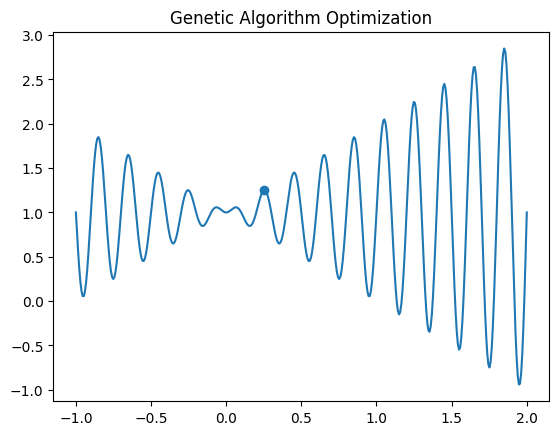

In [ ]:
x = np.linspace(-1, 2, 400)
y = fitness_function(x)

plt.plot(x, y)
plt.scatter(best_solution, best_fitness)
plt.title("Genetic Algorithm Optimization")
plt.show()

# Breast Cancer Case

Tujuan:
Mencari hyperparameter terbaik untuk RandomForestClassifier, yaitu:
* n_estimators
* max_depth
* min_samples_split

Setiap individu dalam populasi merepresentasikan satu kombinasi hyperparameter.

# Import Library

In [ ]:
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier

# Load Dataset

In [ ]:
data = load_breast_cancer()
X = data.data
y = data.target

# Definisi Parameter Space

In [ ]:
param_bounds = {
    "n_estimators": (10, 200),
    "max_depth": (2, 20),
    "min_samples_split": (2, 10)
}

# Inisialisasi Populasi

In [ ]:
def initialize_population(pop_size):
    population = []
    for _ in range(pop_size):
        individual = [
            np.random.randint(*param_bounds["n_estimators"]),
            np.random.randint(*param_bounds["max_depth"]),
            np.random.randint(*param_bounds["min_samples_split"])
        ]
        population.append(individual)
    return np.array(population)

# Fitness Function

In [ ]:
def fitness_function(individual):
    model = RandomForestClassifier(
        n_estimators=int(individual[0]),
        max_depth=int(individual[1]),
        min_samples_split=int(individual[2]),
        random_state=42
    )
    scores = cross_val_score(model, X, y, cv=3)
    return scores.mean()

# Seleksi (Tournament Selection)

In [ ]:
def selection(population, fitness_scores):
    idx1, idx2 = np.random.randint(0, len(population), 2)
    return population[idx1] if fitness_scores[idx1] > fitness_scores[idx2] else population[idx2]

# Crossover

In [ ]:
def crossover(parent1, parent2):
    point = np.random.randint(1, len(parent1))
    child = np.concatenate([parent1[:point], parent2[point:]])
    return child

# Mutasi

In [ ]:
def mutation(individual, mutation_rate=0.1):
    if np.random.rand() < mutation_rate:
        gene_idx = np.random.randint(0, len(individual))
        keys = list(param_bounds.keys())
        bounds = param_bounds[keys[gene_idx]]
        individual[gene_idx] = np.random.randint(*bounds)
    return individual

# Proses Evolusi

In [ ]:
pop_size = 20
generations = 10

population = initialize_population(pop_size)

for gen in range(generations):
    fitness_scores = np.array([fitness_function(ind) for ind in population])
    new_population = []

    for _ in range(pop_size):
        parent1 = selection(population, fitness_scores)
        parent2 = selection(population, fitness_scores)
        child = crossover(parent1, parent2)
        child = mutation(child)
        new_population.append(child)

    population = np.array(new_population)
    print(f"Generation {gen+1}, Best Accuracy: {fitness_scores.max():.4f}")

# Ambil solusi terbaik
fitness_scores = np.array([fitness_function(ind) for ind in population])
best_individual = population[np.argmax(fitness_scores)]

print("\nBest Hyperparameters Found:")
print("n_estimators:", best_individual[0])
print("max_depth:", best_individual[1])
print("min_samples_split:", best_individual[2])
print("Best Accuracy:", fitness_scores.max())

Generation 1, Best Accuracy: 0.9613
Generation 2, Best Accuracy: 0.9613
Generation 3, Best Accuracy: 0.9613
Generation 4, Best Accuracy: 0.9596
Generation 5, Best Accuracy: 0.9596
Generation 6, Best Accuracy: 0.9596
Generation 7, Best Accuracy: 0.9596
Generation 8, Best Accuracy: 0.9596
Generation 9, Best Accuracy: 0.9596
Generation 10, Best Accuracy: 0.9596

Best Hyperparameters Found:
n_estimators: 187
max_depth: 14
min_samples_split: 4
Best Accuracy: 0.9595841455490578


# Genetic Algorithm with pygad

# Library Installation

In [28]:
pip install pygad scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.6/89.6 kB 2.8 MB/s eta 0:00:00


# Import and Data Preparation

In [29]:
import numpy as np
import pygad
from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

# Load dataset
data = load_breast_cancer()
X = data.data
y = data.target

num_features = X.shape[1]
print("Jumlah fitur:", num_features)

Jumlah fitur: 30


# Baseline

In [30]:
model = LogisticRegression(max_iter=500)
baseline_score = cross_val_score(model, X, y, cv=5).mean()

print("Baseline Accuracy:", baseline_score)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

Baseline Accuracy: 0.9525694767893185


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

# Definition of Fitness Function

In [31]:
def fitness_func(ga_instance, solution, solution_idx):
    selected_features = np.where(solution == 1)[0]

    if len(selected_features) == 0:
        return 0

    X_selected = X[:, selected_features]

    model = LogisticRegression(max_iter=500)
    score = cross_val_score(model, X_selected, y, cv=5).mean()

    return score

# Genetic Algorithm Configuration

In [32]:
ga_instance = pygad.GA(
    num_generations=20,
    num_parents_mating=5,
    sol_per_pop=10,
    num_genes=num_features,
    fitness_func=fitness_func,
    gene_type=int,
    init_range_low=0,
    init_range_high=2,
    parent_selection_type="sss",
    crossover_type="single_point",
    mutation_type="random",
    mutation_percent_genes=10
)

# Running Genetic Algorithm

In [33]:
ga_instance.run()

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

# Taking the Best Solution

In [34]:
solution, solution_fitness, _ = ga_instance.best_solution()

selected_features = np.where(solution == 1)[0]

print("Best Accuracy:", solution_fitness)
print("Jumlah fitur terpilih:", len(selected_features))
print("Index fitur:", selected_features)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

Best Accuracy: 0.9560782487191428
Jumlah fitur terpilih: 20
Index fitur: [ 0  1  3  6  8  9 10 11 12 13 15 17 18 19 22 23 25 26 28 29]


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


# Evaluation and Comparison

In [35]:
print("Baseline Accuracy:", baseline_score)
print("GA Accuracy:", solution_fitness)

Baseline Accuracy: 0.9525694767893185
GA Accuracy: 0.9560782487191428


# Convergence Visualization

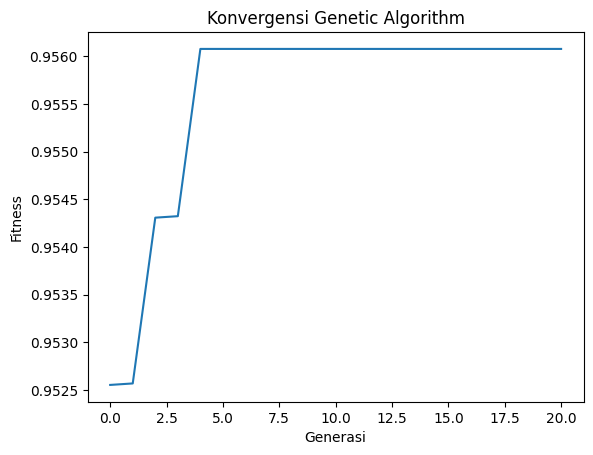

In [36]:
import matplotlib.pyplot as plt

plt.plot(ga_instance.best_solutions_fitness)
plt.xlabel("Generasi")
plt.ylabel("Fitness")
plt.title("Konvergensi Genetic Algorithm")
plt.show()